In [1]:
import pandas as pd

# Load the dataset and compute residual_MWh (same as eda-1.ipynb)
dataset = pd.read_parquet("/Users/ryanaskin/Documents/datasci-challenge/renewables-dataset.parquet")
dataset["Time"] = pd.to_datetime(dataset["Time"])

a_s = 0.01  # solar penetration
a_w = 0.05  # wind penetration
dataset["residual_MWh"] = dataset["demand_MWh"] - (a_s * dataset["solar_MWh"] + a_w * dataset["wind_MWh"])

dataset.head()

,Time,ID,demand_MWh,supply_MWh,solar_MWh,wind_MWh,solar_rel_prod,wind_rel_prod,latitude,longitude,country,solar_layout_MW,wind_layout_MW,residual_MWh
0,2012-01-01 00:00:00+00:00,1,75.6549,9.150821,0.0,18.301642,0.0,0.0284,42.094674,-8.113982,POR,982.8607,644.4240,74.739818
1,2012-01-01 00:00:00+00:00,2,557.8868,6.196411,0.0,12.392822,0.0,0.0103,41.587435,-8.326462,POR,1361.0601,1203.1866,557.267159
2,2012-01-01 00:00:00+00:00,3,15.5237,6.855084,0.0,13.710167,0.0,0.0283,41.585994,-6.722728,POR,746.4879,484.4582,14.838192
3,2012-01-01 00:00:00+00:00,4,8.6425,7.824092,0.0,15.648183,0.0,0.0408,41.597684,-6.342848,POR,456.1251,383.5339,7.860091
4,2012-01-01 00:00:00+00:00,5,85.3649,2.053690,0.0,4.107380,0.0,0.0092,41.373957,-7.350949,POR,986.4986,446.4544,85.159531


In [41]:
dataset["country"].unique()

<ArrowStringArray>
['POR', 'ESP', 'FRA', 'BEL', 'CHE', 'LUX', 'NLD', 'ITA', 'DEU', 'AUT', 'DNK',
 'CZE', 'POL', 'HUN', 'SVK', 'SVN', 'HRV', 'GRC', 'ALB', 'MKD', 'BGR', 'MNE',
 'BIH', 'SRB', 'ROU']
Length: 25, dtype: str

In [24]:
# Sum residual load across all nodes within each country, per timestamp
country_load = dataset.groupby(["country", "Time"])["demand_MWh"].sum().reset_index()

country_load.head()

,country,Time,demand_MWh
0,ALB,2012-01-01 00:00:00+00:00,930.7072
1,ALB,2012-01-01 01:00:00+00:00,915.5938
2,ALB,2012-01-01 02:00:00+00:00,861.6299
3,ALB,2012-01-01 03:00:00+00:00,812.0605
4,ALB,2012-01-01 04:00:00+00:00,768.4864


In [36]:
# Change this to explore a different country, e.g. "DNK", "FRA", "ESP"
country = "DNK"

subset = country_load[country_load["country"] == country]
subset.head()

,country,Time,demand_MWh
210432,DNK,2012-01-01 00:00:00+00:00,3130.8175
210433,DNK,2012-01-01 01:00:00+00:00,3029.1862
210434,DNK,2012-01-01 02:00:00+00:00,2912.4979
210435,DNK,2012-01-01 03:00:00+00:00,2782.6354
210436,DNK,2012-01-01 04:00:00+00:00,2699.8244


<Axes: title={'center': 'Demand load - DNK'}, xlabel='Time'>

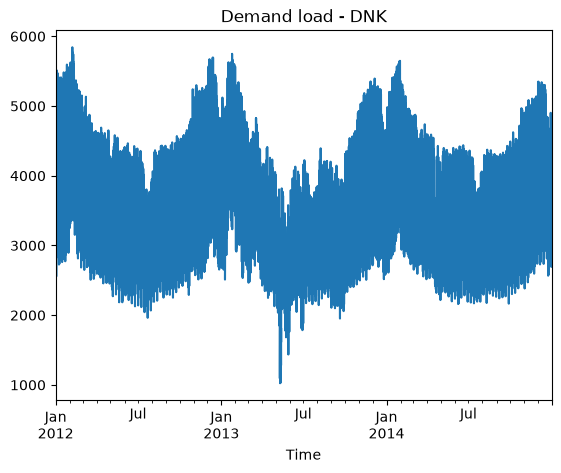

In [37]:
# Residual load over time
subset.plot(x="Time", y="demand_MWh", title=f"Demand load - {country}", legend=False)